In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
import pandas as pd

base_path = "../Daten"
sensors = ["Accelerometer", "Gyroscope", "Orientation"]

def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

raw_dfs = {sensor: [] for sensor in sensors}

measurement_id = 0

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    if os.path.isdir(folder_path):
        try:
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            for sensor in sensors:
                data = pd.read_csv(os.path.join(folder_path, f"{sensor}.csv"))
                data["Sensor"] = sensor
                data["time"] = pd.to_datetime(data["time"])
                data["Tag"] = tag["tag"].iloc[0]
                data["ID"] = measurement_id
                raw_dfs[sensor].append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")
        
        measurement_id += 1  # einmal pro Ordner, nicht pro Sensor

# Zusammenführen und trimmen
dfs = {}
for sensor in sensors:
    raw = pd.concat(raw_dfs[sensor], ignore_index=True)
    raw["ID_backup"] = raw["ID"]
    dfs[sensor] = (
        raw
        .groupby("ID_backup", group_keys=False)
        .apply(trim_measurement)
        .reset_index(drop=True)
    )

# Zugriff auf die einzelnen DataFrames
acc_df  = dfs["Accelerometer"]
gyr_df  = dfs["Gyroscope"]
ori_df  = dfs["Orientation"]

In [4]:
print("Accelerometer-Size:", acc_df.shape)
print("Gyroscope-Size:", gyr_df.shape)
print("Orientation-Size:", ori_df.shape)

Accelerometer-Size: (2133413, 8)
Gyroscope-Size: (1969016, 8)
Orientation-Size: (2081156, 12)


In [5]:
print("Accelerometer columns:", acc_df.columns)
print("Gyroscope columns:", gyr_df.columns)
print("Orientation columns:", ori_df.columns)

Accelerometer columns: Index(['time', 'seconds_elapsed', 'z', 'y', 'x', 'Sensor', 'Tag', 'ID'], dtype='str')
Gyroscope columns: Index(['time', 'seconds_elapsed', 'z', 'y', 'x', 'Sensor', 'Tag', 'ID'], dtype='str')
Orientation columns: Index(['time', 'seconds_elapsed', 'qz', 'qy', 'qx', 'qw', 'roll', 'pitch',
       'yaw', 'Sensor', 'Tag', 'ID'],
      dtype='str')


In [6]:
for name, df in [("Accelerometer", acc_df), ("Gyroscope", gyr_df), ("Orientation", ori_df)]:
    print(f"\n{name}:")
    summary = (
        df.groupby("ID")["seconds_elapsed"]
        .agg(
            Anzahl_Zeilen="count",
            Avg_Diff=lambda x: x.sort_values().diff().mean()
        )
        .reset_index()
    )
    summary["Frequenz_Hz"] = (1 / summary["Avg_Diff"]).round(1)
    print(summary)


Accelerometer:
      ID  Anzahl_Zeilen  Avg_Diff  Frequenz_Hz
0      0           3508  0.008673        115.3
1      1           1297  0.008673        115.3
2      2           1151  0.008673        115.3
3      3           1627  0.008673        115.3
4      4           3355  0.008673        115.3
..   ...            ...       ...          ...
597  597           2708  0.008635        115.8
598  598           2669  0.008592        116.4
599  599           3696  0.008613        116.1
600  600           4229  0.008640        115.7
601  601           1145  0.008673        115.3

[602 rows x 4 columns]

Gyroscope:
      ID  Anzahl_Zeilen  Avg_Diff  Frequenz_Hz
0      0           3508  0.008673        115.3
1      1           1298  0.008673        115.3
2      2           1151  0.008673        115.3
3      3           1627  0.008673        115.3
4      4           3355  0.008673        115.3
..   ...            ...       ...          ...
597  597           2246  0.010389         96.3
598  598

## Vorgehen Merging

Da die drei Sensoren teilweise unterschiedliche Aufnahmefrequenzen haben, besitzen sie unterschiedlich viele Zeilen pro Aufnahme. Um alle Sensoren in einen gemeinsamen Datensatz zusammenzuführen, wird ein einheitliches Zeitraster von 0.02s (50Hz) verwendet.

Dabei wird die Zeit jeder Aufnahme (ID) auf 0 normiert, sodass jede Aufnahme bei t=0 beginnt. Anschliessend werden alle Messwerte innerhalb eines 0.02s-Fensters zum Mittelwert aggregiert (Downsampling von ~115Hz auf 50Hz). Da Accelerometer und Gyroscope beide Spalten mit den Namen x, y und z besitzen, werden diese vor dem Zusammenführen umbenannt (z.B. x_acc, x_gyr), um Verwechslungen zu vermeiden.

In [7]:
def resample_sensor(df, sensor_cols, freq="15ms"):
    result = []
    for id_, group in df.groupby("ID"):
        tag = group["Tag"].iloc[0]
        # Auf 0 normieren
        elapsed_normalized = group["seconds_elapsed"] - group["seconds_elapsed"].min()
        group = group.set_index(
            pd.to_timedelta(elapsed_normalized, unit="s")
        )[sensor_cols]
        group = group.resample(freq).mean()
        group["ID"] = id_
        group["Tag"] = tag
        result.append(group)
    return pd.concat(result).reset_index(names="time_elapsed")

acc_rs  = resample_sensor(acc_df,  ["x", "y", "z"])
gyr_rs  = resample_sensor(gyr_df,  ["x", "y", "z"])
ori_rs  = resample_sensor(ori_df,  ["qx", "qy", "qz", "qw", "roll", "pitch", "yaw"])

# Spalten umbenennen vor dem Merge
acc_rs = acc_rs.rename(columns={"x": "x_acc", "y": "y_acc", "z": "z_acc"})
gyr_rs = gyr_rs.rename(columns={"x": "x_gyr", "y": "y_gyr", "z": "z_gyr"})

# Zusammenführen
merged_df = (
    acc_rs
    .merge(gyr_rs, on=["time_elapsed", "ID", "Tag"])
    .merge(ori_rs,  on=["time_elapsed", "ID", "Tag"])
)

print(merged_df.shape)
print(merged_df.head())

(1220206, 16)
            time_elapsed     x_acc     y_acc     z_acc  ID     Tag     x_gyr  \
0        0 days 00:00:00  7.409234 -1.692557 -3.204165   0  Laufen  1.896277   
1 0 days 00:00:00.015000  6.436191 -4.763577 -3.266069   0  Laufen  1.862069   
2 0 days 00:00:00.030000  3.173627 -5.571195 -3.527226   0  Laufen  1.551138   
3 0 days 00:00:00.045000 -1.031205 -3.811208 -3.934380   0  Laufen  1.209054   
4 0 days 00:00:00.060000 -4.375174 -1.214359 -3.276583   0  Laufen  0.903622   

      y_gyr     z_gyr        qx        qy        qz        qw      roll  \
0  0.928209  0.727082 -0.722047 -0.114941  0.077243  0.677829 -2.568597   
1  1.143539  0.537714 -0.712901 -0.108618  0.075280  0.688689 -2.323276   
2  1.200960  0.210290 -0.706310 -0.101135  0.070940  0.697032 -1.985962   
3  1.414457  0.171500       NaN       NaN       NaN       NaN       NaN   
4  1.365283  0.382249 -0.701441 -0.082747  0.064866  0.704922 -1.467253   

      pitch       yaw  
0  1.488535  2.295729  
1  1.5

In [8]:
# haben wir alle Zeilen
print(merged_df["ID"].nunique())

602


## Achsenausrichtung

Um zu sehen, ob Accelerometer und Gyroscope die gleichen Ausrichtungen für x, y und z haben, werden verschiedene Plots erstellt. Da das Gyproscope die Winkelgeschwindigkeit und das Accelerometer die Beschleunigung ist, sollten die Linien einem ähnlichen Muster folgen, mit einem kurzen Lag dazwischen. 

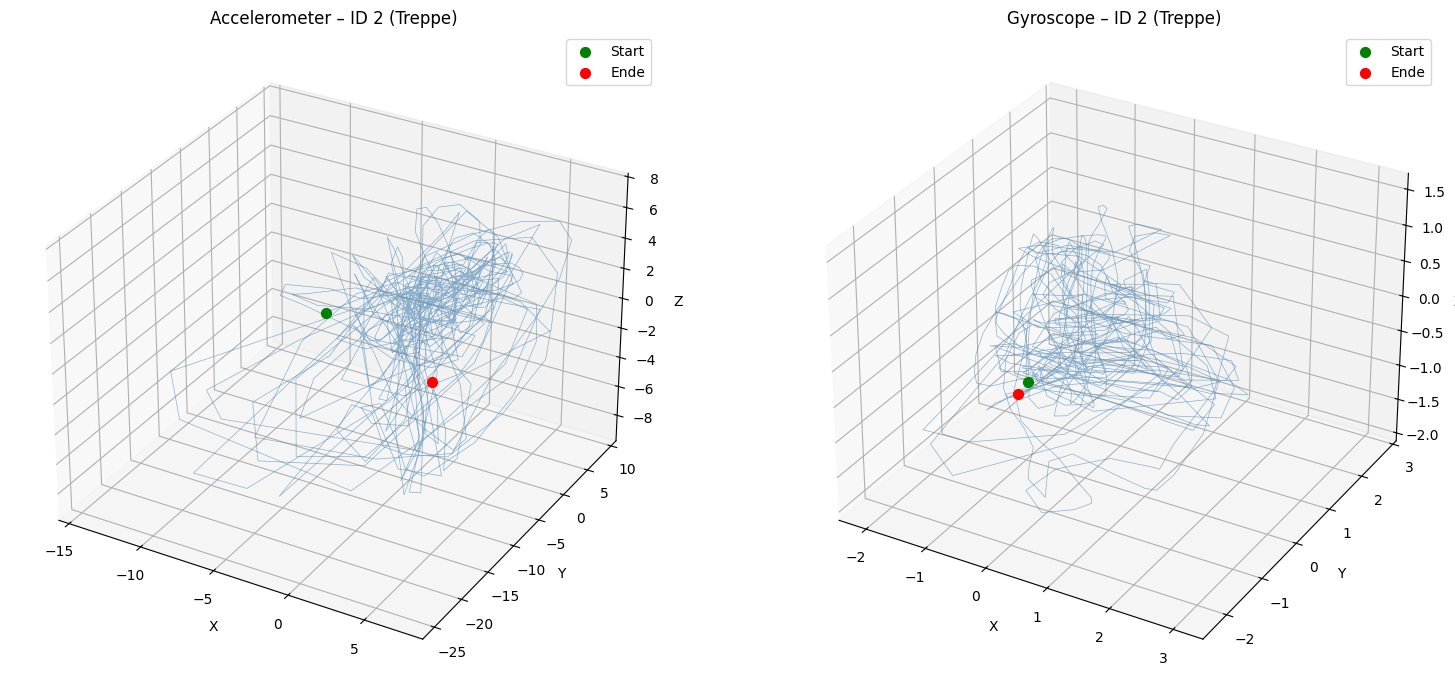

In [32]:
id_to_plot = 2
data = merged_df[merged_df["ID"] == id_to_plot]

fig = plt.figure(figsize=(16, 7))

for i, (sensor, cols) in enumerate([
    ("Accelerometer", ("x_acc", "y_acc", "z_acc")),
    ("Gyroscope",     ("x_gyr", "y_gyr", "z_gyr"))
], start=1):
    ax = fig.add_subplot(1, 2, i, projection='3d')
    x, y, z = data[cols[0]], data[cols[1]], data[cols[2]]
    
    # Linie für den Verlauf
    ax.plot(x, y, z, lw=0.5, alpha=0.6, color="steelblue")
    # Start- und Endpunkt markieren
    ax.scatter(*[v.iloc[0] for v in (x, y, z)], color="green", s=50, zorder=5, label="Start")
    ax.scatter(*[v.iloc[-1] for v in (x, y, z)], color="red",   s=50, zorder=5, label="Ende")
    
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_title(f"{sensor} – ID {id_to_plot} ({data['Tag'].iloc[0]})")
    ax.legend()

plt.tight_layout()
plt.show()

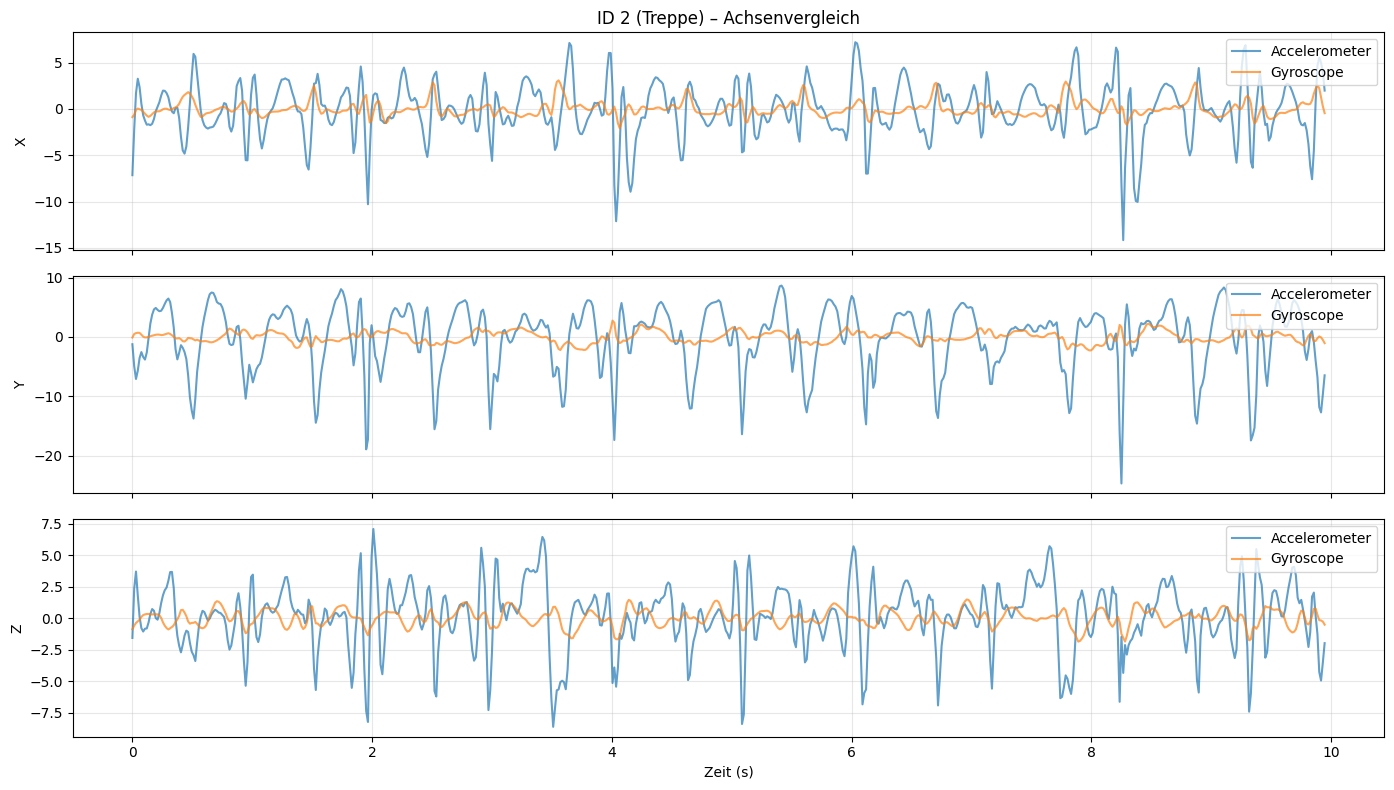

In [31]:
id_to_plot = 2
data = merged_df[merged_df["ID"] == id_to_plot]
time = data["time_elapsed"].dt.total_seconds()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, axis in zip(axes, ["x", "y", "z"]):
    ax.plot(time, data[f"{axis}_acc"], label="Accelerometer", alpha=0.7)
    ax.plot(time, data[f"{axis}_gyr"], label="Gyroscope",     alpha=0.7)
    ax.set_ylabel(axis.upper())
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"ID {id_to_plot} ({data['Tag'].iloc[0]}) – Achsenvergleich")
axes[2].set_xlabel("Zeit (s)")
plt.tight_layout()
plt.show()

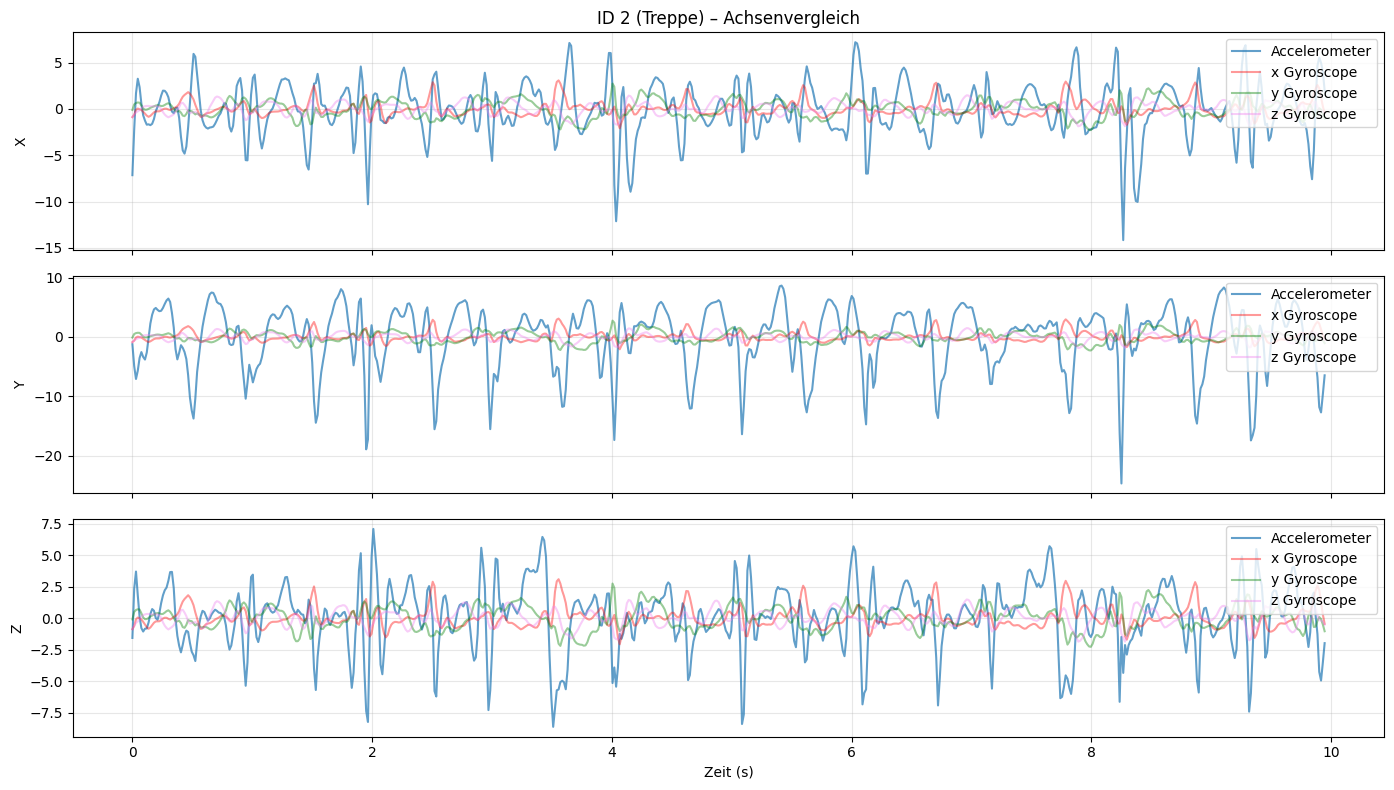

In [30]:
id_to_plot = 2
data = merged_df[merged_df["ID"] == id_to_plot]
time = data["time_elapsed"].dt.total_seconds()

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

for ax, axis in zip(axes, ["x", "y", "z"]):
    ax.plot(time, data[f"{axis}_acc"], label="Accelerometer", alpha=0.7)
    ax.plot(time, data[f"x_gyr"], label="x Gyroscope", alpha=0.4, color="red"), 
    ax.plot(time, data[f"y_gyr"], label="y Gyroscope", alpha=0.4, color="green")
    ax.plot(time, data[f"z_gyr"], label="z Gyroscope", alpha=0.4, color="violet")
    ax.set_ylabel(axis.upper())
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"ID {id_to_plot} ({data['Tag'].iloc[0]}) – Achsenvergleich")
axes[2].set_xlabel("Zeit (s)")
plt.tight_layout()
plt.show()

Basierend auf den Plots sollten es die gleichen Ausrichtungen sein für die jeweiligen Sensoren. 

## Problem

14 hat einen Ausfall bei etwa 11.3 Sekunden, braucht es Interpolation?

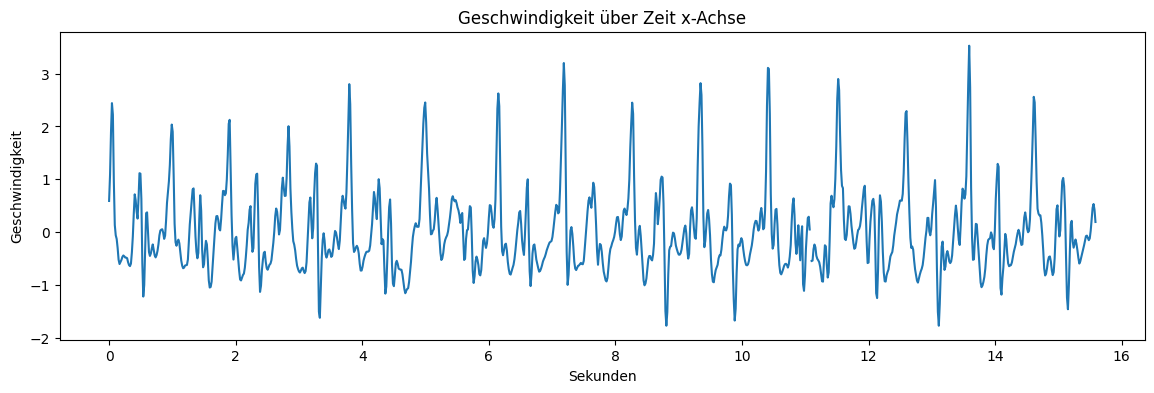

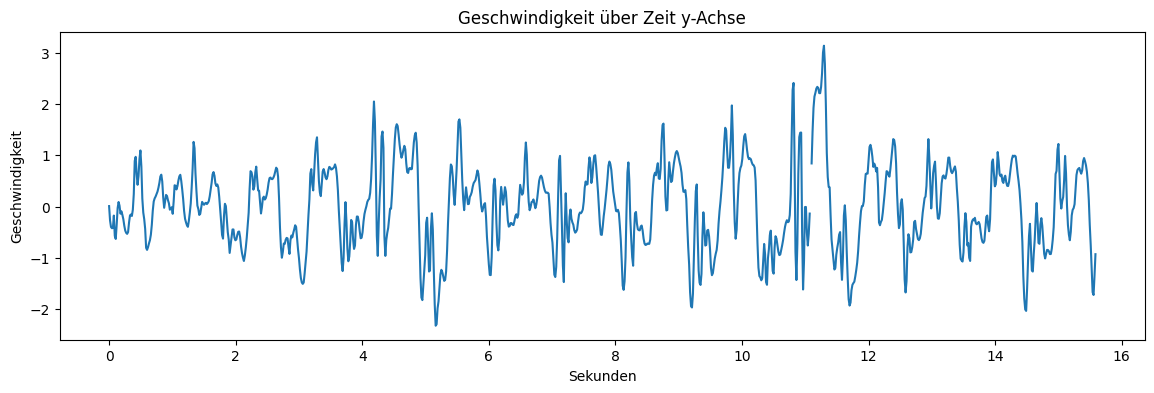

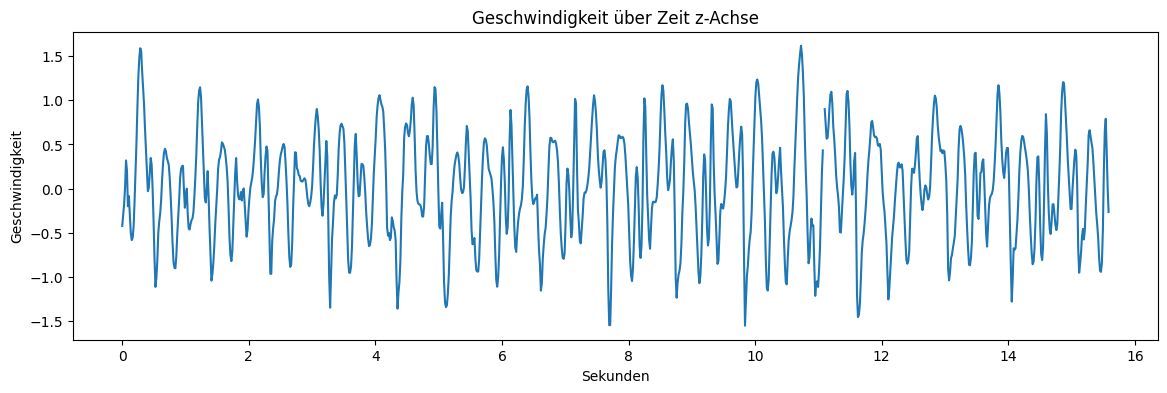

In [34]:
recording_14 = merged_df[merged_df['ID'] == 14]
time_14 = recording_14["time_elapsed"].dt.total_seconds()

#Diagramm mit Sekunden auf der x-Achse und Geschwindigkeit auf der y-Achse.
plt.figure(figsize=(14, 4))
plt.plot(time_14, recording_14["x_gyr"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit x-Achse")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time_14, recording_14["y_gyr"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit y-Achse")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(time_14, recording_14["z_gyr"])
plt.xlabel("Sekunden")
plt.ylabel("Geschwindigkeit")
plt.title("Geschwindigkeit über Zeit z-Achse")
plt.show()

## andere Möglichkeiten

Man könnte auch für jede Aufnahme Statistiken berechnen, wie z.B. mean, median, min, max, q1, q2 etc. und dann nur diese Statistiken reingeben. 